In [1]:
from __future__ import annotations

from operator import add
from typing import TypedDict,Annotated,List,Literal

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END, add_messages
from langgraph.types import Send

from pathlib import Path
import re

from prompts import *

from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage,HumanMessage

from langchain_tavily import TavilySearch

from dotenv import load_dotenv
load_dotenv()

True

`from __future__ import annotations` does not throw error when you instantiate a class that is not yet defined. It does not perform validations (accross type hinting) at runtime rather store them as strings and perform them later. 

Example: In the below example there are two classes referencing each other. When we are creating the class profile the User has not been created but yet used in the during the creation of profile.
```
from __future__ import annotations
class profile:
    def __init__(self,user: User):
        self.user = user
        
class User:
    def __init__(self,profile: Profile):
        self.profile = Profile
```


About the project: We will take the `state['topic']` from the user, according to which orchestrator will create a plan. This plan will contain some N numbers of tasks which will be executed by N number of worker nodes each creating a section (task) of the blog. The output of each worker is stored inside the section. These individual sections are then combined by a reducer and presented as .md file.

In [2]:
class Task(BaseModel):
    id:int = Field("Task ID")
    title: str
    
    goal:str = Field(
        description="a sentence describing what the reader should be able to understand after reading this section."
        )
    
    bullets: List[str] = Field(
        min_length=3,
        max_length=6,
        description="3-6 concrete non-overlapping subpoints to cover in this section."
    )
    
    target_words:int = Field(...,description="Target word count for this section (120-450)", ge=120, le=450)
    tags :List[str] = Field(default_factory=list)
    requires_citation: bool = False
    requires_research: bool = False
    requires_code:bool = False


`...` inside Field means mandatory field; if not present, it is still mandatory.

default uses the same exact object directly but default_factory calls a function to create a new object every time.

If we do `tags: list = []`, the same mutable list can be shared unexpectedly. By using `tags :List[str] = Field(default_factory=list)`, Now every instance gets a fresh new list. 

default is for immutable values like (0, "hello", True) but default_factory is for mutable values (list, dict, set) or dynamically generated values (uuid, timestamps)

List from typing is only a type hint. It describes types for static checking and validation, but it is not meant to create objects. but on the other hand list is the actual Python constructor that will create a new empty list each time.

default_factory or default needs a real callable constructor that creates an object at runtime.

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]
    audience: str = Field(description="type of audience for whom this blog is for.")
    tone:str = Field(description=" Tone of writing (eg. detailed, practical, formal, crisp)")
    constraints:List[str] = Field(default_factory=list)

class RouterDecision(BaseModel):
    needs_research : bool = Field(description="Whether or not the topic requires Internet research. If yes return True else False")
    mode: Literal["closed_book","hybrid","open_book"]
    number_of_search_queries: int = Field(ge=0, le=8, description="Number of search queries")
    search_queries : List[str] = Field(description="List of 3-8 useful search queries")

class EvidenceItem(BaseModel):
    title:str = Field(description="tilte of Evidence Item")
    url:str = Field(description="URL given from tavily")
    content:str = Field(description="Actual Content")

class EvidencePack(BaseModel):
    evidences : List[EvidenceItem] = Field(default_factory=list)


In [4]:
class State(TypedDict):
    topic: str 
    mode : Literal["closed_book","hybrid","open_book"] # Based on which we continue the flow
    plan : Plan
    search_queries: List[str]
    needs_research: bool
    evidences: EvidencePack
    sections : Annotated[List[str],add]
    final: str

`operator.add` is a reducer function that will concatenate the result(str) from each worker inside the list called sections. 

In [5]:
model = ChatOpenAI(model = "gpt-4.1-mini-2025-04-14")

In [6]:
# node that will tell wheather we need to search the internet or not 
def router(state: State) -> dict:
    topic = state['topic']
    decision: RouterDecision = model.with_structured_output(RouterDecision).invoke([
        SystemMessage(content=ROUTER_PROMPT.format(topic= topic))
    ])

    if decision.number_of_search_queries != len(decision.search_queries):
        raise ValueError(
            "number_of_search_queries does not match length of search_queries"
        )
        
    return {"search_queries":decision.search_queries,"needs_research":decision.needs_research,"mode":decision.mode}
    

def route_next(state:State):
    return "research" if state["needs_research"] else "orchestrator"
    

In [7]:
# from langchain_tavily import TavilySearch

# tool = TavilySearch(max_results= 2)
# res = tool.invoke(input= "Who is the lead in the IPL 2026? Who are the runnerups?")
# print(res)

In [8]:
# res['results']

In [9]:
def _tavily_search(query:str, max_results: int = 2):
    tool = TavilySearch(max_results= max_results)
    response = tool.invoke(input = query)

    # URL, Content, Title, Images, Answer
    results = []
    for res in response.get('results',[]):
        results.append({
            "title":res.get('title') or "",
            "url": res.get('url') or "",
            'content':res.get('content') or ""
        })

    return results    

`async def` only creates a coroutine obeject(which is a suspended task that can be executed later). When you actually await the the coroutines the execution starts. You can store the coroutines in a list and and `await async.gather(*stored_coroutines)` to run them concurretly.

In [10]:
def research(state:State) -> dict:
    queries = state['search_queries']

    raw_results : List[dict] = []
    for query in queries:
        result = _tavily_search(query)
        raw_results.append(result)

    if not raw_results:
        return {"evidences":[]}
    
    evidencePack: EvidencePack = model.with_structured_output(EvidencePack).invoke(
        [
            SystemMessage(content = RESEARCH_PROMPT),
            HumanMessage(content=f"Raw Results: \n {raw_results}")
        ]
    )  

    # Deduplicate EvidenceItem by URL
    deduplicate = {}
    for e in evidencePack.evidences:
        if e.url:
            deduplicate[e.url] = e
            
    return {'evidences': list(deduplicate.values())}

In [11]:
def orchestrator(state: State) -> dict:
    mode = state.get("mode","closed_book")
    evidences = state.get('evidences',[])

    plan = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(content = ORCHESTRATOR_PROMPT),
            HumanMessage(content = f"""
                        topic = {state['topic']}\n
                        Mode: {mode}\n
                        Evidence (ONLY FOR FRESH CLAIMS; Can be empty)\n
                        {[e.model_dump() for e in evidences][:20]}
                         """),
        ]
    )
    return {"plan":plan}

Now, we have tasks defined inside the our plan, we need to spawn the worker nodes which we can do using the Send function. Fanout is only a helper function to spawn worker nodes. It is not actually a node itself.

In [12]:
def fanout(state: State) -> List:
    sends = []
    for task in state['plan'].tasks:
        sends.append(Send(
            "worker",arg= {
                "task":task.model_dump(), 
                "plan": state['plan'].model_dump(),
                "topic":state['topic'],
                "mode":state["mode"],
                "evidences": [e.model_dump() for e in state.get("evidences",[])]
                }
            )
        )
    return sends

`.model_dump()` converts the pydantic object into dictionary. .dict() method is deprecated. For EvidenceItem it will be `{url: "https://example.com", "title": "Some title", "content": "Some content"}`

`*` unpacks the elemnts inside the list and send them as individual parameters. In a function parameters you can have `*args` that represents any amount of arguments can be passed to the function. You can also combine two or more lists by unpacking them inside a list.
```
def my_sum(*args):
    res = 0
    for param in args:
        res += param
    return res
    
a = [1,2,3]
b = [5,6,7]    
print(my_sum(*a)) # Output 6
c = [*a,'test',*b] # Output [1,2,3,'test',5,6,7]

6
[1, 2, 3, 'test', 5, 6, 7]
``` 

** unpacks the values inside the dictionary and send them as keyword arguments. In a function parameters you can have `**kwargs` that represent any number of keyword argument can be passed to the function. You can also combine two or more dicts by unpacking them inside a dictionary.

```
def print_args(**kwargs):
    for k,v in kwargs.items():
        print(f"Parameter Name: {k} Paramerter Value {v}")
        
a = {"a":1,"b":2,"c":5,"d":9}
b = {"e":4,"f":7}
print_args(**a)

c = {**a, **b} # 
print(c)

Parameter Name: a Paramerter Value 1
Parameter Name: b Paramerter Value 2
Parameter Name: c Paramerter Value 5
Parameter Name: d Paramerter Value 9
{'a': 1, 'b': 2, 'c': 5, 'd': 9, 'e': 4, 'f': 7}
'''


In [13]:
def worker(payload:dict)-> dict:

    task= Task(**payload['task'])
    plan = Plan(**payload['plan'])
    evidences = [EvidenceItem(**e) for e in payload.get("evidences",[])]
    
    topic = payload['topic']
    mode = payload.get("mode","closed_book")

    bullets = ""
    for bullet in task.bullets:
        bullets += f"\n-{bullet}"

    evidence_text  = ""
    for e in evidences[:20]:
        if e.content:
            evidence_text += f"\n\n{e.title} | {e.url} \n {e.content}".strip()

    section_md = model.invoke(
        [
            SystemMessage(content =  WORKER_PROMPT),
            HumanMessage(
                content = (
                    
                    f"Blog Title: {plan.blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section Title:{task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Constraints: {plan.constraints}"
                    f"Type of Audience: {plan.audience}\n"
                    f"Tone of writing: {plan.tone}\n"
                    f"Mode: {mode}"
                    f"Target Words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"Citation Required: {task.requires_citation}" 
                    f"Requires Research: {task.requires_research}"
                    f"Requires Code:{task.requires_code}"
                    f"Bullets: {bullets}\n"
                    f"Evidence (ONLY Use the URLs when citating):\n{evidence_text}\n"
                )
            )
        ]
    ).content.strip()

    return {"sections":[(task.id,section_md)]}

In [14]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = ""
    for _,section in sorted(state["sections"],key=lambda x:x[0]):
        body += f"\n\n{section}"


    final_md = f"# {title}\n\n{body}\n"

    # Create safe filename, anything that is not a-z or A-Z or 0-9 and -,_ replace with _
    safe_title = re.sub(r'[^a-zA-Z0-9_-]', '_', title.lower())

    output_dir = Path("test_blogs")
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{safe_title}.md"
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [15]:
builder = StateGraph(State)
builder.add_node("router",router)
builder.add_node("research",research)
builder.add_node("orchestrator",action = orchestrator) # Name, fucntion or runnable this node will run
builder.add_node("worker",worker)
builder.add_node("reducer",reducer)

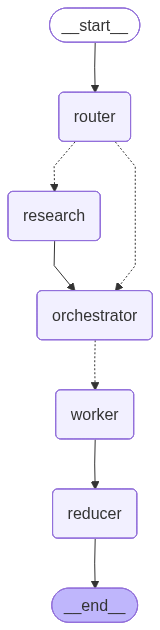

In [16]:
builder.add_edge(START,"router")
builder.add_conditional_edges("router",route_next,path_map={"research":"research","orchestrator":"orchestrator"})
builder.add_edge("research","orchestrator")
builder.add_conditional_edges("orchestrator",fanout,["worker"]) # orchestrator -> fanout -> List of worker nodes
builder.add_edge("worker","reducer")
builder.add_edge("reducer",END)

graph = builder.compile()
graph


In [17]:
response = graph.invoke({"topic":"Latest RAG techniques of 2026"})

In [18]:
response

{'topic': 'Latest RAG techniques of 2026',
 'mode': 'hybrid',
 'plan': Plan(blog_title="Latest RAG Techniques of 2026: A Comprehensive Developer's Guide", tasks=[Task(id=1, title='Understanding the Evolution of RAG Architectures in 2026', goal='Explain the fundamental changes and advancements in RAG architectures from traditional methods to production-grade systems in 2026.', bullets=['Outline the original naive RAG pattern: chunking documents, embedding, cosine similarity search, and prompt stuffing.', 'Describe limitations of naive RAG and why it was mainly a prototype rather than production-ready.', 'Explain the improvements in chunking strategies, context handling, and document ranking introduced in 2026.', 'Discuss the emergence of hybrid retrieval pipelines combining vector and sparse methods like BM25.', 'Highlight how architectural diversity expanded to 16+ RAG design patterns incorporating hybrid and reasoning stacks for accuracy enhancement.'], target_words=450, tags=['archit